# Cardiovascular Disease

In [1]:
import os
import kagglehub

path = kagglehub.dataset_download("sulianova/cardiovascular-disease-dataset")

for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        path = os.path.join(dirname, filename)
# Print out dataset path
path

/home/jm/Documents/code/git/Machine_Learning/Projects/Grade_Prediction/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'/home/jm/.cache/kagglehub/datasets/sulianova/cardiovascular-disease-dataset/versions/1/cardio_train.csv'

In [2]:
import pandas as pd

df = pd.read_csv('/home/jm/.cache/kagglehub/datasets/sulianova/cardiovascular-disease-dataset/versions/1/cardio_train.csv', delimiter=';')

In [3]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [4]:
df.shape

(70000, 13)

In [5]:
df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [7]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
df.drop(columns=['id'], inplace=True)

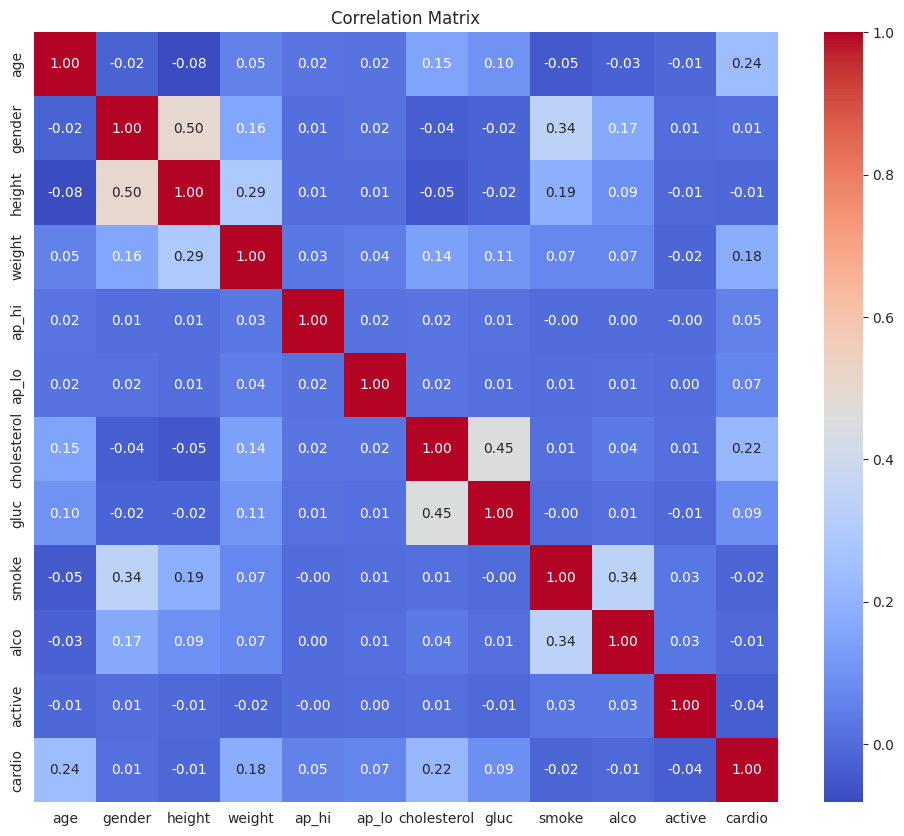

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline
sns.set_style(style="whitegrid")
# Use pearson correlation for continuous variables
corr = df.corr(method='pearson')

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix')
plt.show()

In [10]:
# Drop columns with low correlation to target variable
df.drop(columns=['alco', 'smoke', 'height', 'gender'], inplace=True)

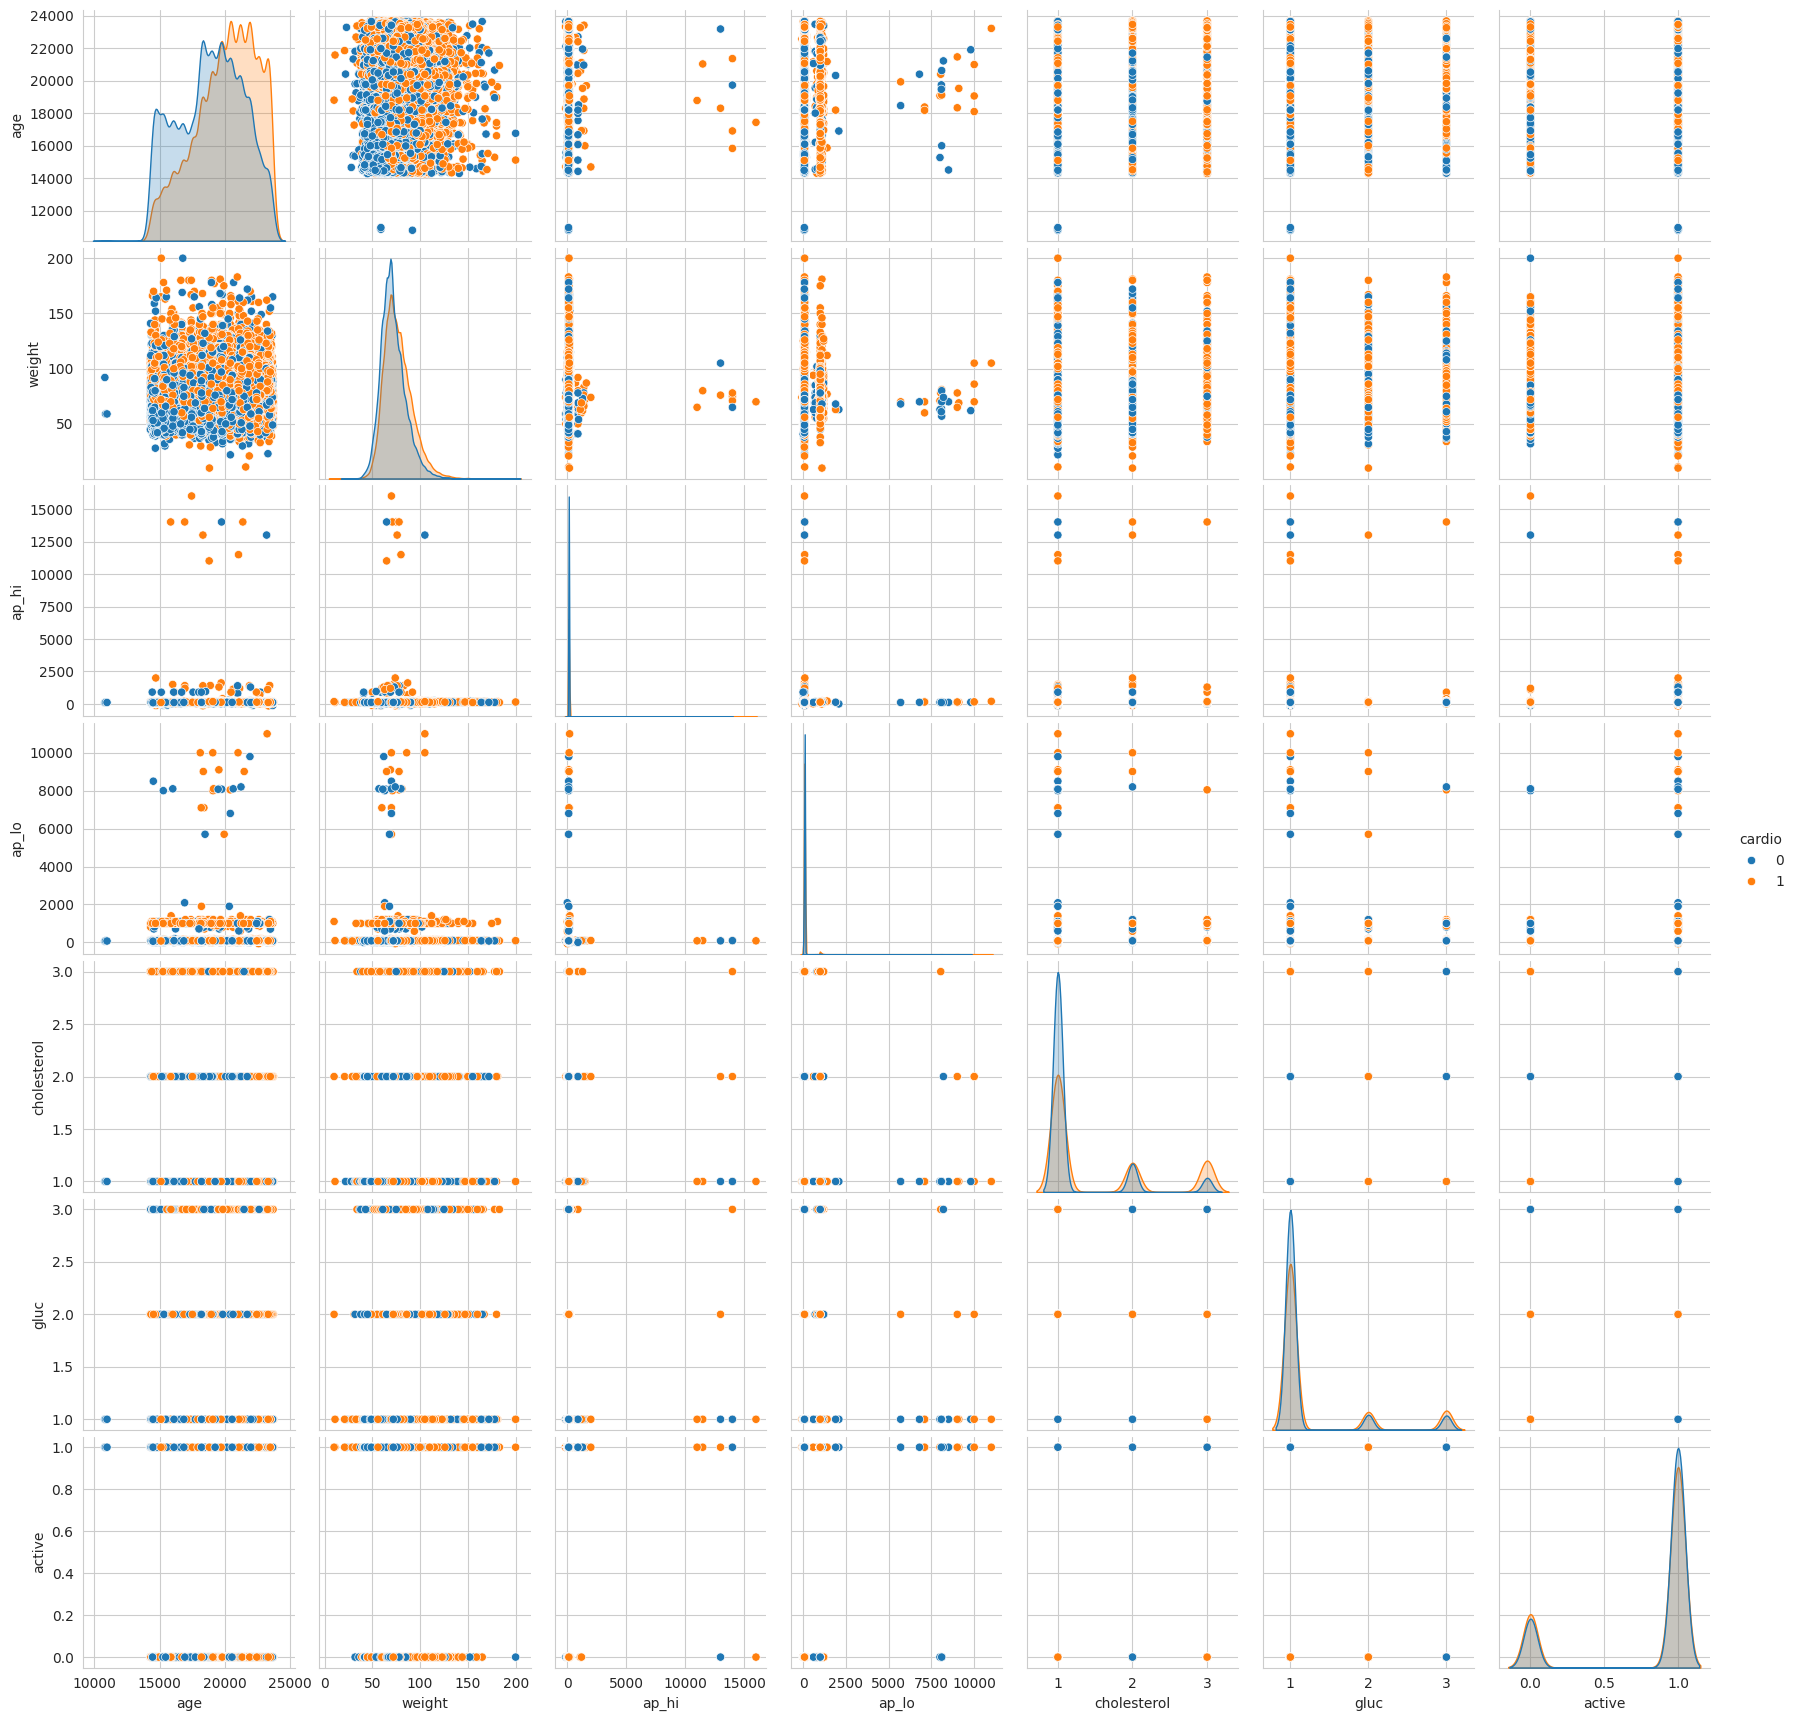

In [11]:
sns.pairplot(df, hue='cardio')

In [12]:
# Feature-target split
X = df.drop(columns=['cardio'])
# Target variable
y = df['cardio']

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

model = LinearRegression()

In [14]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
# Scale features to range [0, 1]
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
# Get intercept of the model
intercept = model.intercept_

print("Intercept:", intercept)

Intercept: -0.24851200701715492


In [17]:
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])

print("Model Coefficients:")
print(coeff_df)

Model Coefficients:
             Coefficient
age             0.529890
weight          0.953980
ap_hi           2.097587
ap_lo           1.434242
cholesterol     0.265889
gluc           -0.046543
active         -0.038527


In [18]:
# make predictions on training and testing sets
y_pred_train = model.predict(X_train)

y_pred_test = model.predict(X_test)

In [19]:
# Create DataFrame to compare actual vs predicted values
y_pred_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_test})
y_pred_df.head(10)

,Actual,Predicted
21955,0,0.334326
24094,1,0.527618
47968,0,0.160599
51361,0,0.673650
19662,1,0.616830
45418,0,0.626295
48735,0,0.699874
48508,1,0.593678
13691,0,0.331025
9972,0,0.427480


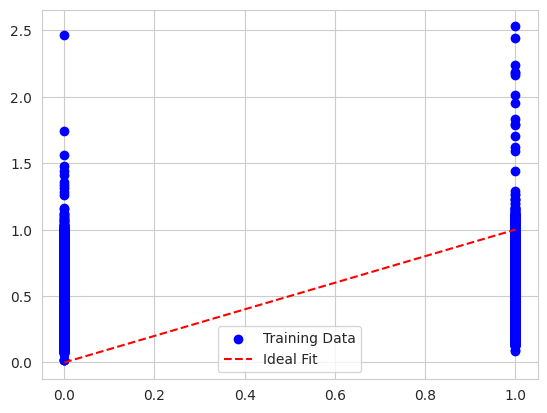

In [20]:
plt.scatter(y_train, y_pred_train, color='blue', label='Training Data')
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], color='red', linestyle='--', label='Ideal Fit')

plt.legend()
plt.show()

In [21]:
from sklearn.metrics import r2_score

train_score = r2_score(y_train, y_pred_train)
print(f"score for training set: {train_score*100:.2f}%")

test_score = r2_score(y_test, y_pred_test)
print(f"score for test set: {test_score*100:.2f}%")

score for training set: 11.92%
score for test set: 11.66%
